## Load Dataset

In [17]:
import pandas as pd

df = pd.read_csv(
    "data/Sample-Superstore.csv",
    encoding="latin1"
)

print(df.shape)
print(df.columns.tolist())

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


## Dataset Inspection

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [19]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Total Revenue

In [21]:
total_sales = df["Sales"].sum()

print(f"Total Revenue: ${total_sales:,.2f}")

Total Revenue: $2,297,200.86


## Total Profit

In [22]:
total_profit = df["Profit"].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


## Sales by Category

In [23]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


## Profit by Category

In [25]:
category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


## Top Products

In [26]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


## Top Performing Region

In [27]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


# VISUALIZATION SECTION

## Importing Libraries

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Chart 1: Sales by Category

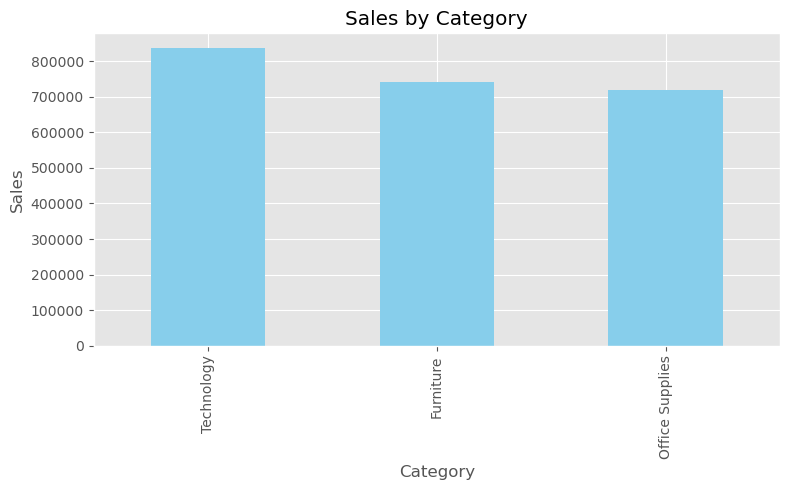

In [29]:
plt.figure(figsize=(8,5))

category_sales.plot(
    kind="bar",
    color="skyblue"
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("sales_by_category.png")

plt.show()

## Chart 2: Profit by Category

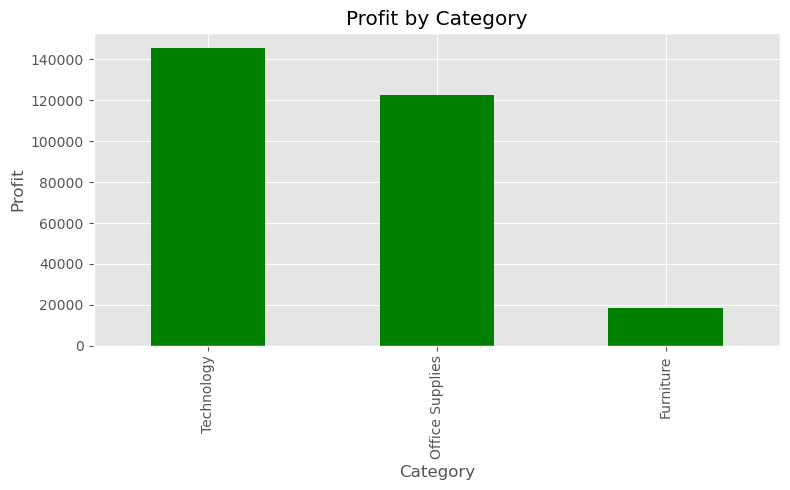

In [35]:
plt.figure(figsize=(8,5))

category_profit.plot(
    kind="bar",
    color="green"
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig("profit_by_category.png")

plt.show()

## Chart 3: Top 10 Products

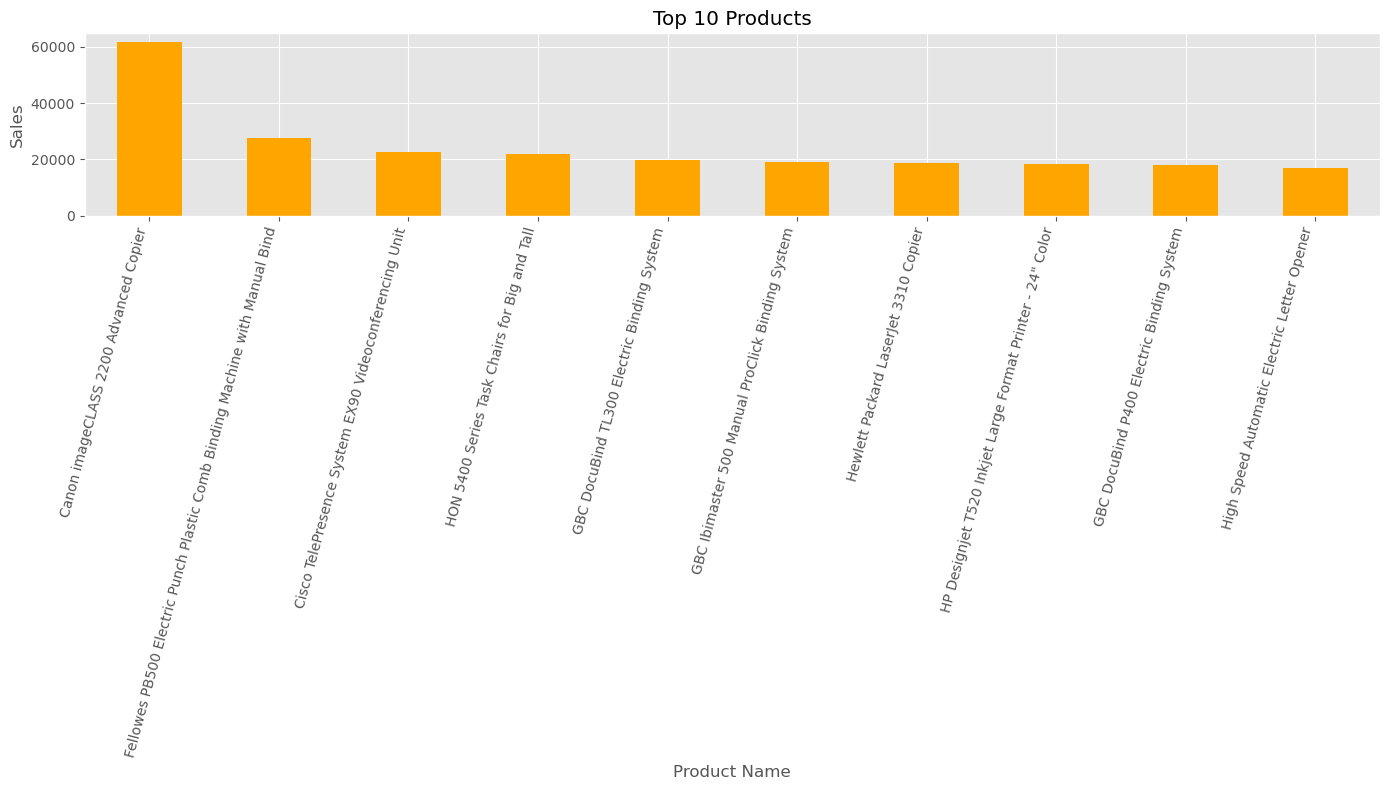

In [42]:
plt.figure(figsize=(14,8))

top_products.plot(
    kind="bar",
    color="orange"
)

plt.title("Top 10 Products")
plt.xlabel("Product Name")
plt.ylabel("Sales")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()

plt.savefig("top_products.png", bbox_inches="tight")

plt.show()

## Chart 4: Sales by Region

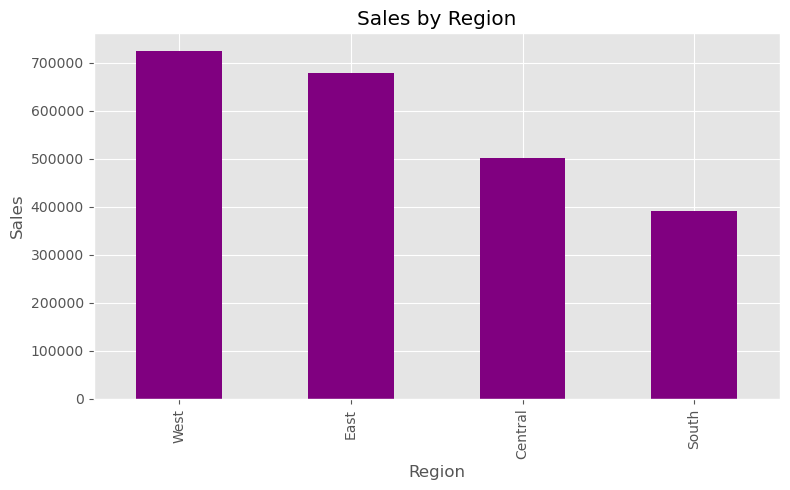

In [43]:
plt.figure(figsize=(8,5))

region_sales.plot(
    kind="bar",
    color="purple"
)

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("region_sales.png")

plt.show()

# MONTHLY SALES TREND

## Convert Date

In [44]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

## Monthly Sales

In [45]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))
    ["Sales"]
    .sum()
)

## Trend Graph

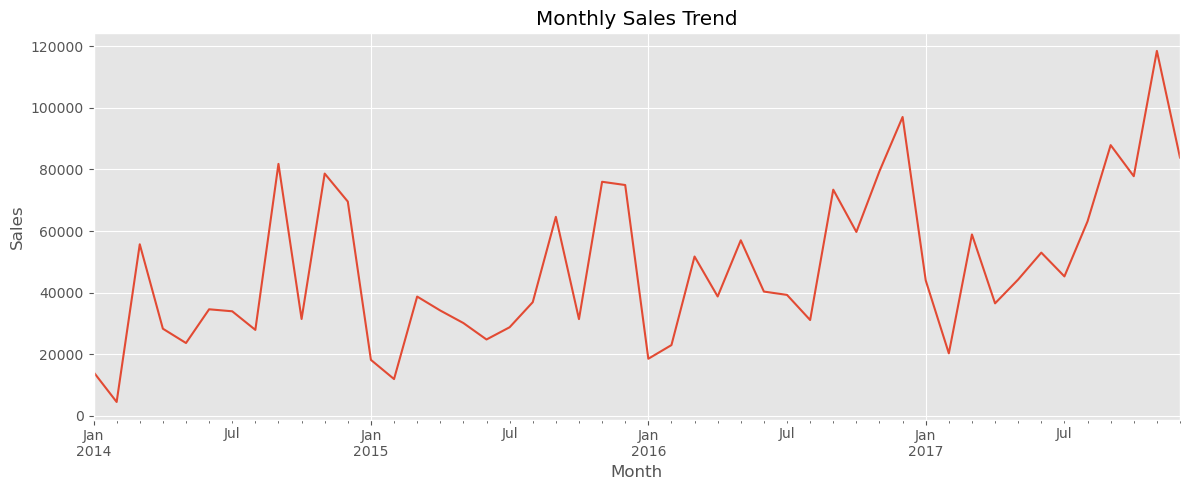

In [46]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("monthly_sales_trend.png")

plt.show()

# Bonus: Pivot Table

In [47]:
pivot_table = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

print(pivot_table)

Category    Furniture  Office Supplies  Technology
Region                                            
Central   163797.1638       167026.415  170416.312
East      208291.2040       205516.055  264973.981
South     117298.6840       125651.313  148771.908
West      252612.7435       220853.249  251991.832
